In [ ]:
!pip install datasets[torch] ffmpeg-python av --quiet underthesea

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

BASE = "/content/drive/MyDrive/VSR_ViCocktail"
os.makedirs(BASE, exist_ok=True)

RAW_CACHE = f"{BASE}/hf_cache"
PROCESSED = f"{BASE}/processed"

os.makedirs(RAW_CACHE, exist_ok=True)
os.makedirs(PROCESSED, exist_ok=True)
os.environ["HF_HOME"] = RAW_CACHE
os.environ["HF_DATASETS_CACHE"] = f"{RAW_CACHE}/datasets"
os.environ["TRANSFORMERS_CACHE"] = f"{RAW_CACHE}/models"


Setup done!


In [ ]:
import datasets
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from wordcloud import WordCloud
import re
import av
import io
import os
from IPython.display import display, Video, HTML
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


CACHE_DIR = None

NUM_SAMPLES_TO_ANALYZE = 5000

print("\n Đang tải dataset...")
dataset = datasets.load_dataset(
    "nguyenvulebinh/ViCocktail",
    split="train",
    cache_dir=CACHE_DIR,
    streaming=True
)


 Đang tải dataset...


Resolving data files:   0%|          | 0/99 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/99 [00:00<?, ?it/s]

In [ ]:
for i, sample in enumerate(dataset):
    if i >= 10:
        break
    print("Sample keys:", sample.keys())
    vid = sample.get("video", None)
    print("Sample index", i, "label:", sample.get("label", None))
    try:
        container = av.open(io.BytesIO(vid["bytes"]))
        frame = next(container.decode(video=0))
        img = frame.to_image()
        display(img.resize((320, 180)))
    except Exception as e:
        print("Không decode video (structure khác):", type(vid), e)


Sample keys: dict_keys(['label', 'length', 'sample_id', 'video', '__key__', '__url__'])
Sample index 0 label: b'd\xc3\xa0nh cho em l\xc3\xa0 mong l\xe1\xbb\x9bn d\xc3\xa0nh cho em d\xc3\xa0nh cho ni\xe1\xbb\x81m \xc4\x91am m\xc3\xaa vi\xe1\xbb\x87n v\xe1\xbb\x9bi b\xc3\xa0 vui l\xe1\xba\xafm l\xe1\xba\xa1i cho s\xc3\xa1t a'
Không decode video (structure khác): <class 'bytes'> byte indices must be integers or slices, not str
Sample keys: dict_keys(['label', 'length', 'sample_id', 'video', '__key__', '__url__'])
Sample index 1 label: b'd\xc3\xa0nh cho em ng\xc3\xa0n c\xc3\xa2u ca v\xc3\xa0 y\xc3\xaau y\xc3\xaau d\xc3\xa0nh cho em tin em kh\xc3\xb4ng bao gi\xe1\xbb\x9d gi\xc3\xa1 d\xc3\xa0nh cho em d\xc3\xa0nh cho em ni\xe1\xbb\x81m \xc4\x91am b\xe1\xba\xbfn'
Không decode video (structure khác): <class 'bytes'> byte indices must be integers or slices, not str
Sample keys: dict_keys(['label', 'length', 'sample_id', 'video', '__key__', '__url__'])
Sample index 2 label: b'\xc3\xb4 s\xe1\xbb\

In [ ]:
from collections import Counter
cnt = 0
label_cnt = Counter()
for i, s in enumerate(dataset):
    cnt += 1
    lbl = s.get("label", "NA")
    label_cnt[lbl] += 1
    if i >= 2000:
        break
print("Checked samples:", cnt)
print("Label sample counts (approx):", label_cnt.most_common()[:20])

Checked samples: 2001
Label sample counts (approx): [(b'hai \xc4\x91\xe1\xba\xb7c \xc4\x91i\xe1\xbb\x83m m\xc3\xa0 c\xc3\xa1c b\xe1\xba\xa1n ch\xc3\xba \xc3\xbd l\xc3\xa0 g\xc3\xac m\xe1\xbb\x99t c\xc3\xb4 g\xc3\xa1i \xc4\x91ang \xc4\x83n c\xc6\xa1m', 2), (b'\xc4\x91i c\xc3\xa1i n\xc3\xa0y ai l\xe1\xbb\xb1a ch\xe1\xbb\x8dn lu\xc3\xb4n', 2), (b'ng\xc6\xb0\xe1\xbb\x9di ta c\xe1\xbb\xa9 \xc4\x91i th\xe1\xba\xa3n nhi\xc3\xaan b\xc3\xacnh th\xc6\xb0\xe1\xbb\x9dng', 2), (b'khi m\xc3\xa0 l\xc3\xa0m kinh doanh ti\xe1\xbb\x81n nhi\xe1\xbb\x81u l\xe1\xba\xafm l\xc3\xbac \xc4\x91\xc3\xb3 m\xe1\xbb\x9bi l\xc3\xa0 l\xc3\xbac \xc4\x91au kh\xe1\xbb\x95 xu\xe1\xba\xa5t hi\xe1\xbb\x87n', 2), (b'd\xc3\xa0nh cho em l\xc3\xa0 mong l\xe1\xbb\x9bn d\xc3\xa0nh cho em d\xc3\xa0nh cho ni\xe1\xbb\x81m \xc4\x91am m\xc3\xaa vi\xe1\xbb\x87n v\xe1\xbb\x9bi b\xc3\xa0 vui l\xe1\xba\xafm l\xe1\xba\xa1i cho s\xc3\xa1t a', 1), (b'd\xc3\xa0nh cho em ng\xc3\xa0n c\xc3\xa2u ca v\xc3\xa0 y\xc3\xaau y\xc3\xaau d\xc3\xa0nh ch

In [ ]:
def process_sample(sample):
    """Xử lý một 'sample' và trả về metadata."""
    try:
        transcript = bytes(sample['label']).decode('utf-8')
    except Exception:
        transcript = None

    duration = np.nan
    try:
        with io.BytesIO(sample['video']) as byte_stream:
            with av.open(byte_stream, 'r') as container:
                stream = container.streams.video[0]
                duration = stream.duration * float(stream.time_base)
    except Exception:
        pass

    if transcript:
        return {
            'transcript': transcript,
            'video_duration_sec': duration,
            'transcript_length_char': len(transcript),
            'transcript_length_word': len(transcript.split())
        }
    return None

print(f"Đang xử lý và thu thập {NUM_SAMPLES_TO_ANALYZE} mẫu...")





Đang xử lý và thu thập 5000 mẫu...


Đã thu thập xong. Đang chuyển sang Pandas DataFrame...
Số mẫu bị lỗi (video hoặc text): 0

--- 1. Cấu trúc dữ liệu (DataFrame) ---
Phân tích trên 5000 mẫu hợp lệ.
                                          transcript  video_duration_sec  \
0  dành cho em là mong lớn dành cho em dành cho n...               12.00   
1  dành cho em ngàn câu ca và yêu yêu dành cho em...                9.36   
2                ô sờ e tờ sen tai con mờ cô bóp lai                2.36   
3  sâu dít tờ ô sâu vin a pô dít sừn kết ét i m i...                8.52   
4                                      tờ tia sơ hen                2.28   

   transcript_length_char  transcript_length_word  
0                      90                      23  
1                     108                      27  
2                      35                      11  
3                      72                      20  
4                      13                       4  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to

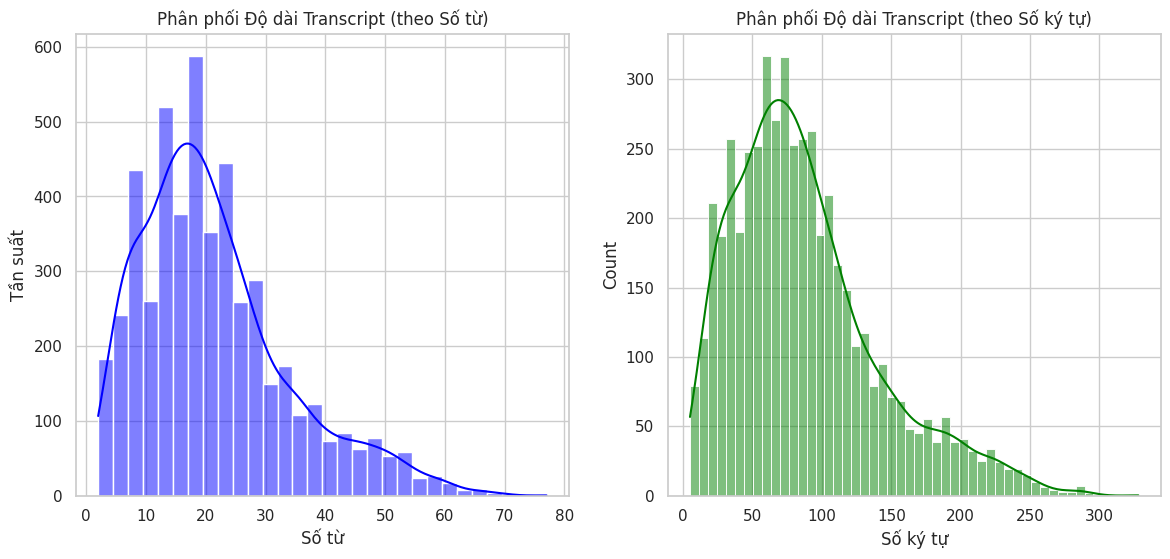

       transcript_length_char  transcript_length_word  video_duration_sec
count             5000.000000             5000.000000         5000.000000
mean                87.633400               21.302800            5.285816
std                 53.233653               12.600574            2.926112
min                  5.000000                2.000000            0.600000
25%                 49.000000               12.000000            3.320000
50%                 78.000000               19.000000            4.760000
75%                113.000000               27.000000            6.690000
max                328.000000               77.000000           15.000000


In [ ]:
metadata_list = []

for sample in dataset.take(NUM_SAMPLES_TO_ANALYZE):
    processed_data = process_sample(sample)
    if processed_data:
        metadata_list.append(processed_data)

print(f"Đã thu thập xong. Đang chuyển sang Pandas DataFrame...")

df = pd.DataFrame(metadata_list)
print(f"Số mẫu bị lỗi (video hoặc text): {df['video_duration_sec'].isna().sum()}")
df_cleaned = df.dropna()

print("\n--- 1. Cấu trúc dữ liệu (DataFrame) ---")
print(f"Phân tích trên {len(df_cleaned)} mẫu hợp lệ.")
print(df_cleaned.head())
print(df_cleaned.info())

print("\n[Bước 2] Đang phân tích và trực quan hóa Transcripts...")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df_cleaned['transcript_length_word'], kde=True, bins=30, color="blue")
plt.title('Phân phối Độ dài Transcript (theo Số từ)')
plt.xlabel('Số từ')
plt.ylabel('Tần suất')

plt.subplot(1, 2, 2)
sns.histplot(df_cleaned['transcript_length_char'], kde=True, bins=50, color="green")
plt.title('Phân phối Độ dài Transcript (theo Số ký tự)')
plt.xlabel('Số ký tự')
plt.show()

print(df_cleaned[['transcript_length_char', 'transcript_length_word', 'video_duration_sec']].describe())




Đang tạo Word Cloud (đã loại bỏ stopwords)...


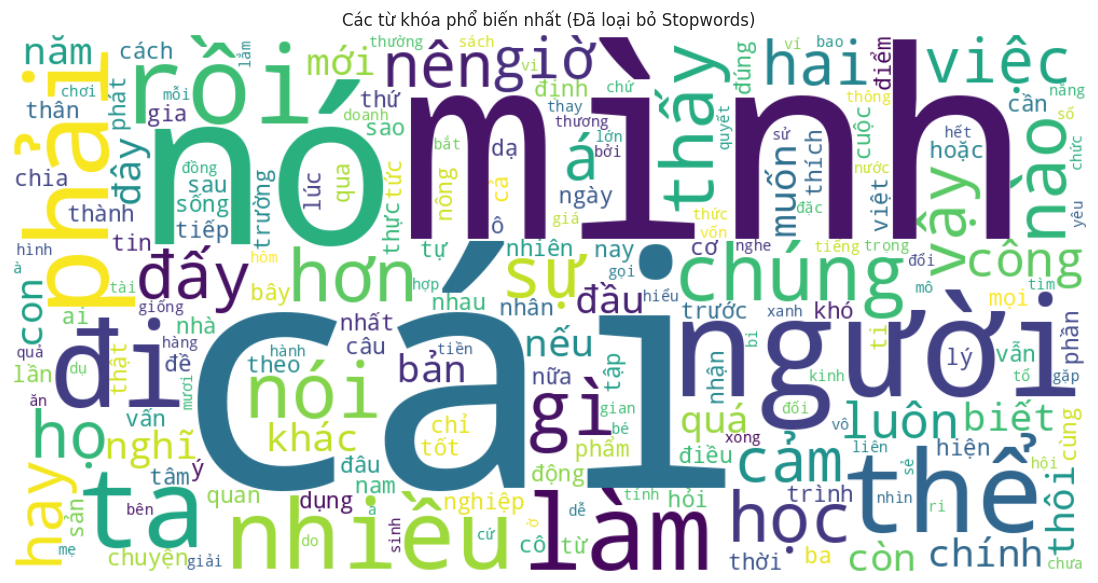


[Bước 3] Thực hiện Processing nhẹ và kiểm tra ảnh hưởng...
Kích thước từ vựng (chưa processing): 2708 từ
Kích thước từ vựng (đã processing): 2708 từ
=> ẢNH HƯỞNG: Giảm 0 từ.


In [ ]:
print("\nĐang tạo Word Cloud (đã loại bỏ stopwords)...")
all_text = " ".join(df_cleaned['transcript'])

# THÊM VÀO ĐÂY:
# Tự định nghĩa một danh sách stopwords Tiếng Việt cơ bản
# Bạn có thể thêm nhiều từ hơn nếu muốn
vietnamese_stopwords = set([
    'và', 'của', 'là', 'cho', 'có', 'không', 'được', 'với', 'trong', 'để',
    'thì', 'như', 'tôi', 'bạn', 'anh', 'em', 'chị', 'ông', 'bà', 'này',
    'đó', 'kia', 'khi', 'mà', 'vì', 'nhưng', 'bị', 'một', 'những', 'các',
    'rằng', 'lại', 'ra', 'vào', 'lên', 'xuống', 'trên', 'dưới', 'cũng',
    'đã', 'sẽ', 'đang', 'rất', 'tới', 'đến', 'về', 'ở', 'tại', 'ấy', 'thế'
])

# Dòng wordcloud này bây giờ sẽ chạy đúng
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    collocations=False,
    stopwords=vietnamese_stopwords # <-- Dùng danh sách vừa tạo
).generate(all_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Các từ khóa phổ biến nhất (Đã loại bỏ Stopwords)')
plt.show()

# ... (phần còn lại của code) ...


# --- Bước 3: Thử nghiệm "Processing Nhẹ" (Giữ nguyên) ---
# Phần này cũng giữ nguyên
print("\n[Bước 3] Thực hiện Processing nhẹ và kiểm tra ảnh hưởng...")
def light_text_processing(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

vocab_before = set(" ".join(df_cleaned['transcript']).split())
df_cleaned['processed_transcript'] = df_cleaned['transcript'].apply(light_text_processing)
vocab_after = set(" ".join(df_cleaned['processed_transcript']).split())

print(f"Kích thước từ vựng (chưa processing): {len(vocab_before)} từ")
print(f"Kích thước từ vựng (đã processing): {len(vocab_after)} từ")
print(f"=> ẢNH HƯỞNG: Giảm {len(vocab_before) - len(vocab_after)} từ.")


In [ ]:
import base64
import io
import tempfile
import os
from IPython.display import display, HTML, Video, clear_output
import av

def _is_valid_video_bytes(video_bytes):
    """Trả về (True, duration_seconds) nếu av có thể đọc được, ngược lại (False, 0)."""
    try:
        with io.BytesIO(video_bytes) as bs:
            with av.open(bs, 'r') as container:
                # lấy stream video đầu tiên (nếu có)
                streams = [s for s in container.streams if s.type == 'video']
                if not streams:
                    return False, 0.0
                stream = streams[0]
                if stream.duration is None or stream.time_base is None:
                    # có thể vẫn đọc được, cố gắng tính frame count
                    return True, 0.0
                duration = float(stream.duration) * float(stream.time_base)
                return True, duration
    except Exception as e:
        return False, 0.0

def display_video_bytes(video_bytes, mime_type="video/mp4", width=480, height=360, max_embed_bytes=8_000_000):
    """
    Hiển thị video từ bytes:
    - ưu tiên base64 embed (nếu size <= max_embed_bytes)
    - fallback: ghi file tạm và dùng IPython.display.Video
    Trả về dict kết quả để debug.
    """
    result = {"method": None, "error": None, "duration": None, "tmp_path": None}
    try:
        # Kiểm tra xem av có đọc được và lấy thời lượng (nếu có)
        ok, duration = _is_valid_video_bytes(video_bytes)
        result["duration"] = duration

        # Nếu nhỏ hơn ngưỡng -> encode base64 và nhúng HTML5
        if len(video_bytes) <= max_embed_bytes:
            b64 = base64.b64encode(video_bytes).decode('utf-8')
            html = f'''
            <video width="{width}" height="{height}" controls>
              <source src="data:{mime_type};base64,{b64}" type="{mime_type}">
              Your browser does not support the video tag.
            </video>
            '''
            display(HTML(html))
            result["method"] = "base64_embed"
            return result

        # Nếu quá lớn hoặc embed thất bại -> ghi file tạm
        # Lưu trữ vào /tmp hoặc thư mục tạm colab
        fd, tmp_path = tempfile.mkstemp(suffix=".mp4")
        os.close(fd)
        with open(tmp_path, "wb") as f:
            f.write(video_bytes)
        result["tmp_path"] = tmp_path
        display(Video(tmp_path, embed=True, width=width, height=height, html_attributes=["controls"]))
        result["method"] = "tempfile"
        return result

    except Exception as e:
        result["error"] = str(e)
        # Cuối cùng: nếu mọi thứ thất bại, thử hiển thị raw Video object (có thể ném lỗi)
        try:
            display(Video(io.BytesIO(video_bytes), embed=True, width=width, height=height, html_attributes=["controls"]))
            result["method"] = "display_raw"
        except Exception as e2:
            result["error"] += " | fallback error: " + str(e2)
        return result

# Phiên bản hàm cho dataset streaming (sử dụng .skip().take(1))
def display_streaming_sample(dataset, index_to_skip, video_field="video", label_field="label",
                             width=480, height=360, max_embed_bytes=8_000_000):
    """
    dataset: dataset streaming (HuggingFace) hoặc bất kỳ iterable tương tự với .skip().take(1)
    index_to_skip: index muốn nhảy tới
    video_field: tên key chứa bytes video trong sample
    label_field: tên key chứa transcript/label
    """
    try:
        print(f"--- Lấy mẫu index {index_to_skip} ")
        sample = next(iter(dataset.skip(index_to_skip).take(1)))

        # Một số dataset trả về memoryview / bytearray / bytes
        video_bytes = sample[video_field]
        if isinstance(video_bytes, memoryview):
            video_bytes = video_bytes.tobytes()
        elif isinstance(video_bytes, bytearray):
            video_bytes = bytes(video_bytes)
        # transcript có thể là bytes hoặc str
        label = sample[label_field]
        if isinstance(label, (bytes, bytearray, memoryview)):
            try:
                label = bytes(label).decode('utf-8')
            except:
                label = str(label)

        # Kiểm tra video có đọc được
        ok, duration = _is_valid_video_bytes(video_bytes)
        if ok:
            print(f"> Video có thể giải mã được. Thời lượng xấp xỉ: {duration:.2f} giây." if duration else "> Video có thể giải mã được (thời lượng không xác định).")
        else:
            print("! Cảnh báo: av không thể giải mã video (có thể file corrupt hoặc không phải mp4). Thử ghi file tạm để xem.")

        # Hiển thị transcript
        display(HTML(f"<div style='font-family:Arial,sans-serif;'><b>Transcript (index {index_to_skip}):</b> <i>{label}</i></div>"))

        # Hiển thị video (base64 hoặc tempfile trong hàm)
        result = display_video_bytes(video_bytes, width=width, height=height, max_embed_bytes=max_embed_bytes)
        print("Kết quả hiển thị:", result)
        print("\n\n")
    except StopIteration:
        print(f"Không thể lấy mẫu tại index {index_to_skip}: dataset kết thúc sớm.")
    except Exception as e:
        print(f"Lỗi khi hiển thị mẫu {index_to_skip}: {e}")


In [ ]:
indices_to_show = [10, 203]
for idx in indices_to_show:
     display_streaming_sample(dataset, idx)

--- Lấy mẫu index 10 
> Video có thể giải mã được. Thời lượng xấp xỉ: 2.36 giây.


Kết quả hiển thị: {'method': 'base64_embed', 'error': None, 'duration': 2.36, 'tmp_path': None}



--- Lấy mẫu index 203 
> Video có thể giải mã được. Thời lượng xấp xỉ: 1.64 giây.


Kết quả hiển thị: {'method': 'base64_embed', 'error': None, 'duration': 1.6400000000000001, 'tmp_path': None}





In [ ]:
indices_to_show = [364,1942]
for idx in indices_to_show:
     display_streaming_sample(dataset, idx)

--- Lấy mẫu index 364 
> Video có thể giải mã được. Thời lượng xấp xỉ: 1.08 giây.


Kết quả hiển thị: {'method': 'base64_embed', 'error': None, 'duration': 1.08, 'tmp_path': None}



--- Lấy mẫu index 1942 
> Video có thể giải mã được. Thời lượng xấp xỉ: 5.28 giây.


Kết quả hiển thị: {'method': 'base64_embed', 'error': None, 'duration': 5.28, 'tmp_path': None}



